Importation

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

Declaring dataset

In [2]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

df = pd.read_csv(
    "dataset/adult.data",
    names=columns,
    skipinitialspace=True
)

Display

In [3]:
#print(df.head())
print(df.shape)
#print(df.columns)
#print(df['income'])
print("-------------------------------")
print("-------------------------------")
for each in columns:
    print(df[each].value_counts())
    print("-------------------------------")

(32561, 15)
-------------------------------
-------------------------------
age
36    898
31    888
34    886
23    877
35    876
     ... 
83      6
88      3
85      3
86      1
87      1
Name: count, Length: 73, dtype: int64
-------------------------------
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
-------------------------------
fnlwgt
164190    13
123011    13
203488    13
126675    12
121124    12
          ..
94638      1
292353     1
337895     1
180296     1
422249     1
Name: count, Length: 21648, dtype: int64
-------------------------------
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-sc

In [4]:
print(((df['workclass'] == '?') + (df['occupation'] == '?')).sum())
print(((df['workclass'] == '?') & (df['occupation'] == '?')).sum())
print(((df['native-country'] == '?') & (df['occupation'] == '?')).sum())

print('percentage of corrupted data: '+str(round(((df['workclass'] == '?') + (df['occupation'] == '?')).sum()/df.shape[0]*100, 2))+'%')

1843
1836
27
percentage of corrupted data: 5.66%


Through this observation we understand that each row that has '?' as value for workclass, has '?' as value for occupation, with the surplus of 7 in occupation. While native country doesnt fully belong to the latter.

deleting all no value rows in occupation and native country as they form around 6% of our dataset.

In [5]:
dfc=df[df['occupation'] != '?'].copy()
dfc=dfc[dfc['native-country'] != '?'].copy()


print(dfc.shape)
print(dfc.columns)


(30162, 15)
Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')


Using labelEncoder to replace non numerical values forthe workclass feature.

In [6]:
dfct=dfc.copy()

#workclass
encoderWC = LabelEncoder()
dfct['workclass']= encoderWC.fit_transform(dfc['workclass'])
print("Signification of each number for the encoded workclass: "+encoderWC.classes_)


dfct['workclass']


['Signification of each number for the encoded workclass: Federal-gov'
 'Signification of each number for the encoded workclass: Local-gov'
 'Signification of each number for the encoded workclass: Private'
 'Signification of each number for the encoded workclass: Self-emp-inc'
 'Signification of each number for the encoded workclass: Self-emp-not-inc'
 'Signification of each number for the encoded workclass: State-gov'
 'Signification of each number for the encoded workclass: Without-pay']


0        5
1        4
2        2
3        2
4        2
        ..
32556    2
32557    2
32558    2
32559    2
32560    3
Name: workclass, Length: 30162, dtype: int64

Deleting the duplicated education feature and encoding it.

In [7]:
dfct = dfct.drop('education-num', axis=1)
encoderED = LabelEncoder()
dfct['education']= encoderED.fit_transform(dfc['education'])
print("Signification of each number for the encoded education: "+encoderED.classes_)


dfct['education']

['Signification of each number for the encoded education: 10th'
 'Signification of each number for the encoded education: 11th'
 'Signification of each number for the encoded education: 12th'
 'Signification of each number for the encoded education: 1st-4th'
 'Signification of each number for the encoded education: 5th-6th'
 'Signification of each number for the encoded education: 7th-8th'
 'Signification of each number for the encoded education: 9th'
 'Signification of each number for the encoded education: Assoc-acdm'
 'Signification of each number for the encoded education: Assoc-voc'
 'Signification of each number for the encoded education: Bachelors'
 'Signification of each number for the encoded education: Doctorate'
 'Signification of each number for the encoded education: HS-grad'
 'Signification of each number for the encoded education: Masters'
 'Signification of each number for the encoded education: Preschool'
 'Signification of each number for the encoded education: Prof-s

0         9
1         9
2        11
3         1
4         9
         ..
32556     7
32557    11
32558    11
32559    11
32560    11
Name: education, Length: 30162, dtype: int64

Encoding marital status.

In [8]:
encoderMS = LabelEncoder()
dfct['marital-status']= encoderMS.fit_transform(dfc['marital-status'])
print("Signification of each number for the encoded marital status: "+encoderMS.classes_)


dfct['marital-status']

['Signification of each number for the encoded marital status: Divorced'
 'Signification of each number for the encoded marital status: Married-AF-spouse'
 'Signification of each number for the encoded marital status: Married-civ-spouse'
 'Signification of each number for the encoded marital status: Married-spouse-absent'
 'Signification of each number for the encoded marital status: Never-married'
 'Signification of each number for the encoded marital status: Separated'
 'Signification of each number for the encoded marital status: Widowed']


0        4
1        2
2        0
3        2
4        2
        ..
32556    2
32557    2
32558    6
32559    4
32560    2
Name: marital-status, Length: 30162, dtype: int64

Encoding occupation.

In [9]:
encoderOC= LabelEncoder()
dfct['occupation']= encoderOC.fit_transform(dfc['occupation'])
print("Signification of each number for the encoded occupation: "+encoderOC.classes_)


dfct['occupation']

['Signification of each number for the encoded occupation: Adm-clerical'
 'Signification of each number for the encoded occupation: Armed-Forces'
 'Signification of each number for the encoded occupation: Craft-repair'
 'Signification of each number for the encoded occupation: Exec-managerial'
 'Signification of each number for the encoded occupation: Farming-fishing'
 'Signification of each number for the encoded occupation: Handlers-cleaners'
 'Signification of each number for the encoded occupation: Machine-op-inspct'
 'Signification of each number for the encoded occupation: Other-service'
 'Signification of each number for the encoded occupation: Priv-house-serv'
 'Signification of each number for the encoded occupation: Prof-specialty'
 'Signification of each number for the encoded occupation: Protective-serv'
 'Signification of each number for the encoded occupation: Sales'
 'Signification of each number for the encoded occupation: Tech-support'
 'Signification of each number fo

0         0
1         3
2         5
3         5
4         9
         ..
32556    12
32557     6
32558     0
32559     0
32560     3
Name: occupation, Length: 30162, dtype: int64

Encoding relationship.

In [11]:
encoderRS= LabelEncoder()
dfct['relationship']= encoderRS.fit_transform(dfc['relationship'])
print("Signification of each number for the encoded relationship: "+encoderRS.classes_)


dfct['relationship']

['Signification of each number for the encoded relationship: Husband'
 'Signification of each number for the encoded relationship: Not-in-family'
 'Signification of each number for the encoded relationship: Other-relative'
 'Signification of each number for the encoded relationship: Own-child'
 'Signification of each number for the encoded relationship: Unmarried'
 'Signification of each number for the encoded relationship: Wife']


0        1
1        0
2        1
3        0
4        5
        ..
32556    5
32557    0
32558    4
32559    3
32560    5
Name: relationship, Length: 30162, dtype: int64

Encoding race.

In [12]:
encoderRA= LabelEncoder()
dfct['race']= encoderRA.fit_transform(dfc['race'])
print("Signification of each number for the encoded race: "+encoderRA.classes_)


dfct['race']

['Signification of each number for the encoded race: Amer-Indian-Eskimo'
 'Signification of each number for the encoded race: Asian-Pac-Islander'
 'Signification of each number for the encoded race: Black'
 'Signification of each number for the encoded race: Other'
 'Signification of each number for the encoded race: White']


0        4
1        4
2        4
3        2
4        2
        ..
32556    4
32557    4
32558    4
32559    4
32560    4
Name: race, Length: 30162, dtype: int64

Encoding sex.

In [13]:
encoderSex= LabelEncoder()
dfct['sex']= encoderSex.fit_transform(dfc['sex'])
print("Signification of each number for the encoded sex: "+encoderSex.classes_)


dfct['sex']

['Signification of each number for the encoded sex: Female'
 'Signification of each number for the encoded sex: Male']


0        1
1        1
2        1
3        1
4        0
        ..
32556    0
32557    1
32558    0
32559    1
32560    0
Name: sex, Length: 30162, dtype: int64

Encoding native country.

In [14]:
encoderNC= LabelEncoder()
dfct['native-country']= encoderNC.fit_transform(dfc['native-country'])
print("Signification of each number for the encoded native-country: "+encoderNC.classes_)


dfct['native-country']

['Signification of each number for the encoded native-country: Cambodia'
 'Signification of each number for the encoded native-country: Canada'
 'Signification of each number for the encoded native-country: China'
 'Signification of each number for the encoded native-country: Columbia'
 'Signification of each number for the encoded native-country: Cuba'
 'Signification of each number for the encoded native-country: Dominican-Republic'
 'Signification of each number for the encoded native-country: Ecuador'
 'Signification of each number for the encoded native-country: El-Salvador'
 'Signification of each number for the encoded native-country: England'
 'Signification of each number for the encoded native-country: France'
 'Signification of each number for the encoded native-country: Germany'
 'Signification of each number for the encoded native-country: Greece'
 'Signification of each number for the encoded native-country: Guatemala'
 'Signification of each number for the encoded native

0        38
1        38
2        38
3        38
4         4
         ..
32556    38
32557    38
32558    38
32559    38
32560    38
Name: native-country, Length: 30162, dtype: int64

Encoding income.

In [21]:
encoderIN= LabelEncoder()
dfct['income']= encoderIN.fit_transform(dfc['income'])
print('Signification of 1 for the encoded income: <=50K\nSignification of 0 for the encoded income: >50K')

dfct['income'] = 1 - dfct['income']
dfct['income']

Signification of 1 for the encoded income: <=50K
Signification of 0 for the encoded income: >50K


0        1
1        1
2        1
3        1
4        1
        ..
32556    1
32557    0
32558    1
32559    1
32560    0
Name: income, Length: 30162, dtype: int64

Setting coorelation matrix of features with target

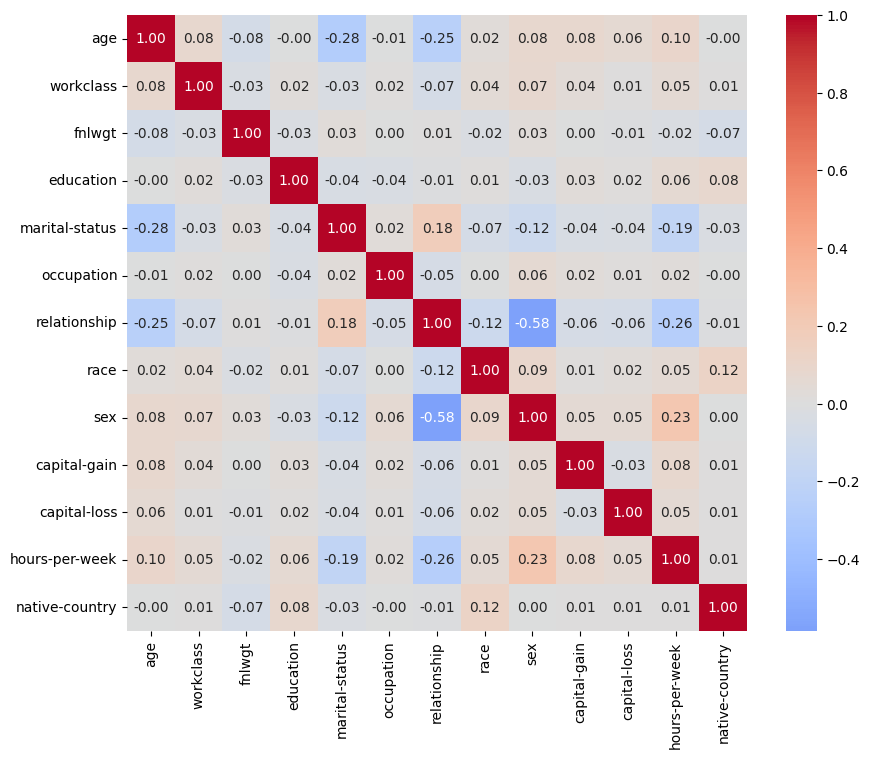

In [15]:
corr = dfct.corr(numeric_only=True)          # Pearson by default

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

In [22]:
dfct.drop(columns="income").corrwith(dfct["income"])

age              -0.241998
workclass        -0.018044
fnlwgt            0.008957
education        -0.078987
marital-status    0.193518
occupation       -0.051577
relationship      0.251003
race             -0.071658
sex              -0.216699
capital-gain     -0.221196
capital-loss     -0.150053
hours-per-week   -0.229480
native-country   -0.023268
dtype: float64